In [1]:
import pandas as pd

D:\anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df1= pd.DataFrame(
    {
        'Ename':['Kunal','Sanju','Raju','Amit'],
        'Eid':[102,103,104,105],
        'Sal':['10LPA','20LPA','10LPA','11LPA']
    }
)
df1

,Ename,Eid,Sal
0,Kunal,102,10LPA
1,Sanju,103,20LPA
2,Raju,104,10LPA
3,Amit,105,11LPA


In [3]:
df2= pd.DataFrame(
    {    'Eid':[102,103,104,109,108,105],
        'Bonus':[200,500,320,120,103,104],
        'Location':['Goa','JK','UK','AP','Nala','NM']
    }
)
df2

,Eid,Bonus,Location
0,102,200,Goa
1,103,500,JK
2,104,320,UK
3,109,120,AP
4,108,103,Nala
5,105,104,NM


#Concatenation
It is a process of merging two and more DataFrame
###    1) Vertical: row by row
    Syntax:-      pd.concat([val1,val2,..... val3])
### 2) Horizonatal:- Col by col
  syntax:- pd.concat([var1,var2.......],axis=1)

In [4]:
pd.concat([
    df1,df2
])

,Ename,Eid,Sal,Bonus,Location
0,Kunal,102,10LPA,NaN,NaN
1,Sanju,103,20LPA,NaN,NaN
2,Raju,104,10LPA,NaN,NaN
3,Amit,105,11LPA,NaN,NaN
0,NaN,102,NaN,200.0,Goa
1,NaN,103,NaN,500.0,JK
2,NaN,104,NaN,320.0,UK
3,NaN,109,NaN,120.0,AP
4,NaN,108,NaN,103.0,Nala
5,NaN,105,NaN,104.0,NM


In [5]:
pd.concat([
    df1,df2
],axis=1)

,Ename,Eid,Sal,Eid,Bonus,Location
0,Kunal,102.0,10LPA,102,200,Goa
1,Sanju,103.0,20LPA,103,500,JK
2,Raju,104.0,10LPA,104,320,UK
3,Amit,105.0,11LPA,109,120,AP
4,NaN,NaN,NaN,108,103,Nala
5,NaN,NaN,NaN,105,104,NM


# Joins
if we want to ferch the data from wo different tables similtaneously we se joins.

## Types of Joins
1) Inner Join
2) Left Join
3) Right Join
4) Outer 

### Syntax:- 
pd.merge(var1,var2,on='column_col',how='inner/Left/right/outer')

df1

In [6]:
df1


,Ename,Eid,Sal
0,Kunal,102,10LPA
1,Sanju,103,20LPA
2,Raju,104,10LPA
3,Amit,105,11LPA


In [7]:
df2

,Eid,Bonus,Location
0,102,200,Goa
1,103,500,JK
2,104,320,UK
3,109,120,AP
4,108,103,Nala
5,105,104,NM


### Inner Join:-
It return only match  records from both the data frame 

In [8]:
pd.merge(df1,df2,on='Eid',how='inner')

,Ename,Eid,Sal,Bonus,Location
0,Kunal,102,10LPA,200,Goa
1,Sanju,103,20LPA,500,JK
2,Raju,104,10LPA,320,UK
3,Amit,105,11LPA,104,NM


### Left Join :
i will return all the records from left DataFrame abf matching Records from right DataFrame,

In [9]:
pd.merge(df1,df2,on='Eid',how='left')

,Ename,Eid,Sal,Bonus,Location
0,Kunal,102,10LPA,200,Goa
1,Sanju,103,20LPA,500,JK
2,Raju,104,10LPA,320,UK
3,Amit,105,11LPA,104,NM


### Right Join :
i will return all the records from Right DataFrame of matching Records from left DataFrame,

In [10]:
pd.merge(df1,df2,on='Eid',how='right')

,Ename,Eid,Sal,Bonus,Location
0,Kunal,102,10LPA,200,Goa
1,Sanju,103,20LPA,500,JK
2,Raju,104,10LPA,320,UK
3,NaN,109,NaN,120,AP
4,NaN,108,NaN,103,Nala
5,Amit,105,11LPA,104,NM


### Outer Join :
i will return all the records from both the data frame

In [11]:
pd.merge(df1,df2,on='Eid',how='outer')

,Ename,Eid,Sal,Bonus,Location
0,Kunal,102,10LPA,200,Goa
1,Sanju,103,20LPA,500,JK
2,Raju,104,10LPA,320,UK
3,Amit,105,11LPA,104,NM
4,NaN,108,NaN,103,Nala
5,NaN,109,NaN,120,AP


### Feature Engineering:-
it is a process of creating new columns  from existing data 

## Syntax:-
####   var[col_name]=new_val

In [12]:
titnic=pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/titanic.csv')

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [ ]:
titnic

In [ ]:
titnic['family_count_without']=titnic['sibsp'] + titnic['parch']

In [ ]:
titnic

In [ ]:
# Create a new column of family name 
titnic['sr name ']= titnic['name'].str.split(',').str[0]

In [ ]:
# split using for loop 
out=[]
for i in titnic['name']:
    out.append(i.split(',')[0])
titnic['faimily_name']= out
titnic


In [ ]:
titnic

In [ ]:
titnic['miss/mr']= titnic['name'].str.split('.').str[0].str.split(',').str[1]

In [ ]:
titnic

In [ ]:
###

In [ ]:
#####  Pivot_Table():-
#it s also known as power house of pandas 
#it in use to apply multiple aggreigation function of multiple columnns at the same time.

# Syntax :-      var.pivot_table(values=[col1,col2,............coln],
#                                 index= 'categorical_column',
#                                   aggfunc= ['fname','fname2',...........fname n]
                                                                                       )


In [ ]:
titnic.pivot_table(values=['age','fare'],
                  index= 'sex',
                  aggfunc= ['mean','count'])

In [ ]:
titnic.pivot_table(values=['name'],
                  index= 'sex',
                  aggfunc= ['count'])

In [ ]:
# Count of employee who are working and left 
hr = pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/hr_data.csv')

In [ ]:
hr

In [ ]:
hr.pivot_table(
                 values=['employee_id'],
                 index= 'left',
                  aggfunc='count'
                 
)

In [ ]:
###

In [ ]:
###  Data-Range():
# Syntax:-    pd.date_range(start='MM/DD/YYYY',
#                           end= 'MM/DD/YYYY',
#                             freq='char')
#   D-Daily
#   w-weekly(Sunday -Sunday)
#    W-Mon :- weekly(From Monday to Monday)
#    MS :- Month Start
#    ME :- Month End 
#     B :- BUsiness Week Mon- Friday
#    YS :- Year Start     {to start the month  [YS-MAR]}
#    YE :- Year End 
#     2D :-   Gap of 2Days , after 2 Days

In [ ]:
pd.date_range(start='18-10-2019',
               end='21-11-2025',
               freq='W-Tue')

In [ ]:
#  pd.to_datetime(var['col_name'])
pd.to_datetime

In [ ]:
hr.info()

In [2]:
af= pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/amazon_fires.csv',encoding='ISO-8859-1')
af

RemoteDisconnected: Remote end closed connection without response

In [ ]:
af['Date']= pd.to_datetime(af['Datetime'])

## Data Visuliation :- 
    It is a process of converting the data in pictorial and grapical  representation to understand the data  to better understanding

### 3 ways:- 
####   1) Matplotlib
####   2)   Seaborn
####    3)  PowerBI



# 1) Matplotlib

In [2]:
import matplotlib.pyplot as plt
import numpy as np

###  Plot() 
      it is used to create a 2D Graph
      Syntax :- plt.plt(X,Y)

In [3]:
X= np.arange(1,11)
Y= X**2
Z=X**3
A=X**4

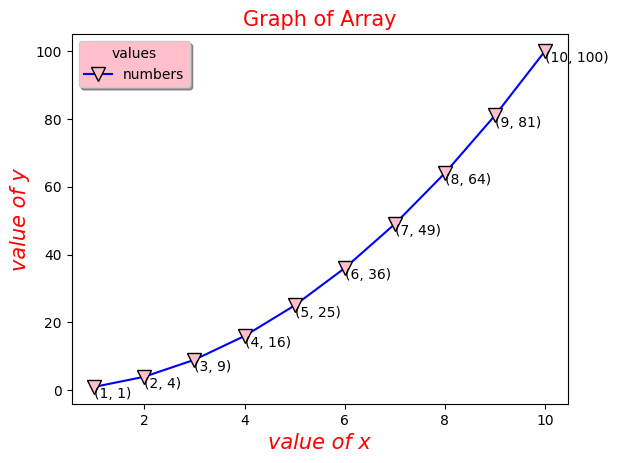

In [4]:
plt.plot(X,Y,label='numbers',marker='v',markersize=10, markerfacecolor='pink', markeredgecolor='black',color= 'blue')

plt.legend(title='values',shadow=True,facecolor='pink',loc='best',)
plt.xlabel('value of x',color='red',fontsize=15,fontstyle='italic')
plt.ylabel('value of y',color='red',fontsize=15,fontstyle='oblique')
plt.title('Graph of Array',fontsize=15,color='red',fontstyle='normal')


# Annotate():-
for i in range(len(X)):
    plt.annotate(f'({X[i]}, {Y[i]})',(X[i],Y[i]),va='top',ha='left')
plt.show()

In [5]:
## Argument of plot 
# Marker= it is use to mark the point[+,x,p,s,d,h,.,v]
# Markersize= it will modify the size of the point
# Markerfacecolor:- it use to change the color of the point 
# Markeredgecolor:- it will change the color of edge
# color:- it will changw the color of whole line/graph
# linewidth = it will change the width of the line
# linestyle= it change the style of the line [--,-,dotted]

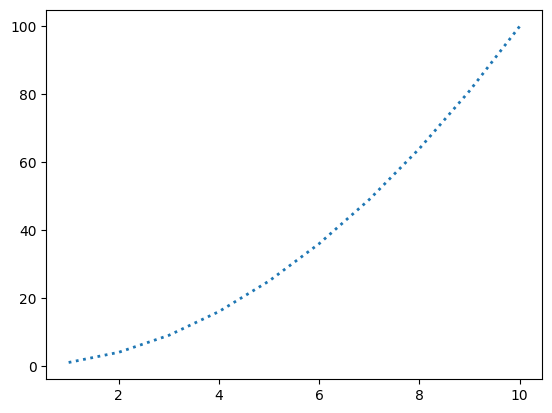

In [6]:
plt.plot(X,Y,linewidth=2, linestyle='dotted')

In [7]:
# Argument legend:-
# shadow = True/False
# Facecolor324e
#location := loc='upper left'/lower left /uppp30er right / best /center
# 

### SUB Plot

In [8]:
df= pd.read_csv('Sales_If,If-else,Switch.csv')
df.head(4)

,OrderID,Region,Sales_Amount,Profit
0,1001,North,12000,3000
1,1002,South,8000,1200
2,1003,East,15000,4000
3,1004,West,6000,800


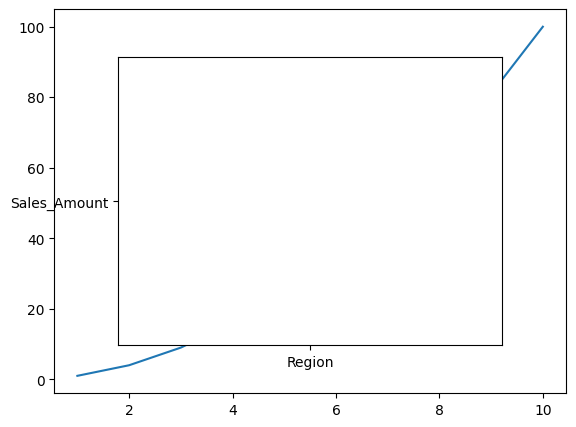

In [9]:
# var=plt.figure()
#var.add_axes([left,bottom,weight,height])

fig=plt.figure()
in1 = fig.add_axes([0.1,0.1,0.8,0.8])
in2 = fig.add_axes([0.2,0.2,0.6,0.6])

in1.plot(X,Y)
in2.plot(['Region'],['Sales_Amount'])
                                            

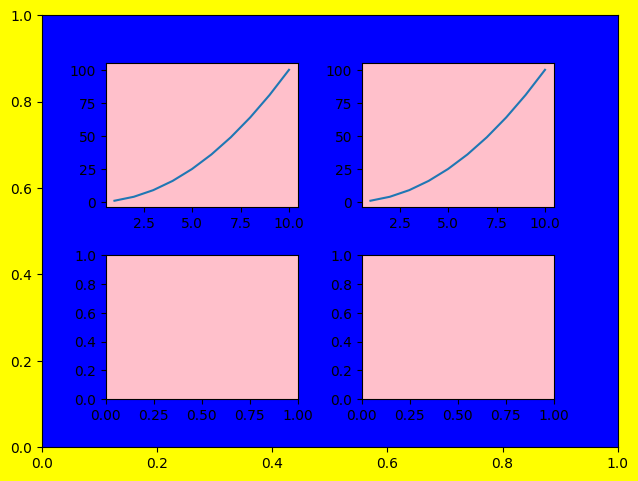

In [10]:
k = plt.figure(facecolor='yellow')
k.add_axes([0.1,0.1,0.9,0.9],facecolor='blue')
a1 = k.add_axes([0.2,0.6,0.3,0.3],facecolor='pink')
a2=k.add_axes([0.6,0.6,0.3,0.3],facecolor='pink')
k.add_axes([0.2,0.2,0.3,0.3],facecolor='pink')
k.add_axes([0.6,0.2,0.3,0.3],facecolor='pink')
a1.plot(X,Y)
a2.plot(X,Y)

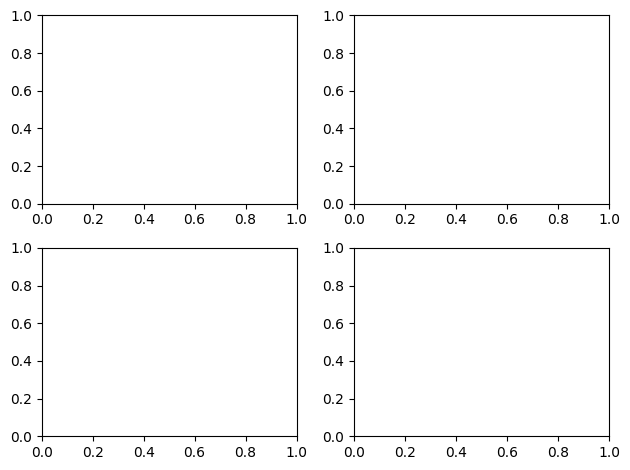

In [29]:
### Subplot():-
### fig,axes=plt.subplot(nrow=val,ncol=val)
### axes[row,col].plot()

fig,axes= plt.subplots(nrows=2,ncols=2)
plt.tight_layout()

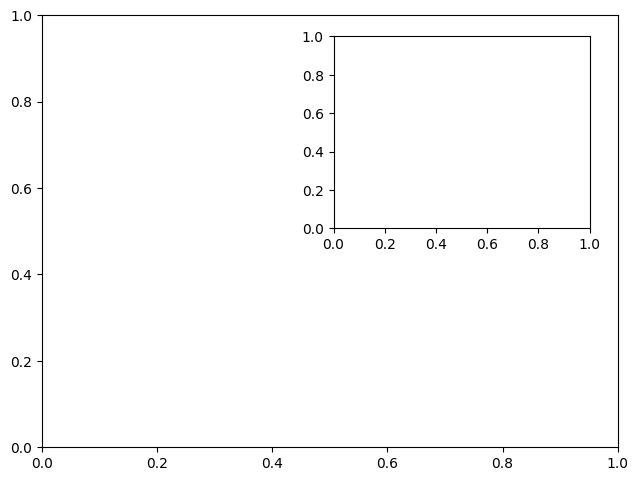

In [12]:
var= plt.figure()
grid_1= var.add_axes([0.4,0.4,0.9,0.9])
grid_2=var.add_axes([0.856,0.856,0.4,0.4])

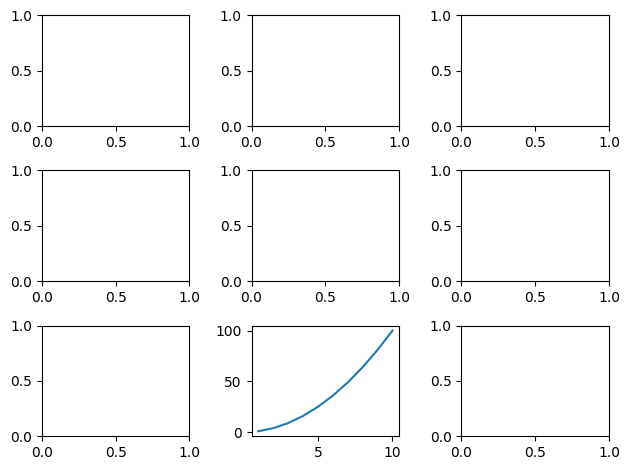

In [13]:
fig,axes= plt.subplots(nrows=3,ncols=3)
axes[2,1].plot(X,Y)
plt.tight_layout()

In [14]:
# Pie Plot:- 
## To represent Data in the form of percentage
## Syntax:-  
#           plt.pie(data,labels=[],autopct='%0.2f%%', color=[].shadow=True,explode=())


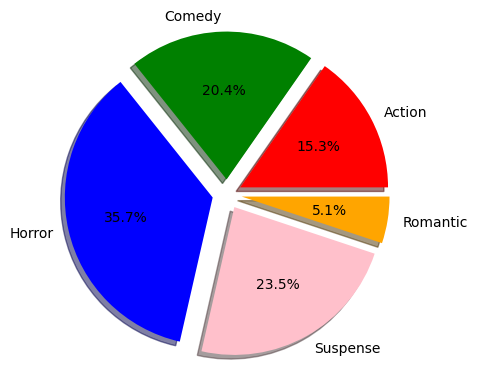

In [15]:
lab= ['Action','Comedy','Horror','Suspense','Romantic']
views=[1500,2000,3500,2300,500]
plt.pie(views,labels=lab,colors=['red','green','blue','pink','orange'],autopct='%0.1f%%',shadow=True,explode=(0.1,0.1,0.1,0.1,0.1))
plt.show()

In [16]:
## Create a pie chart that represents
# the count of live and diwd in titanic
# dataset

In [25]:
titnic=pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/titanic.csv')

In [30]:
titnic.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1


In [31]:
ser= titnic[titnic['survived']==1]['survived'].count()
dead= titnic[titnic['survived']==0]['survived'].count()

In [32]:
dead

np.int64(809)

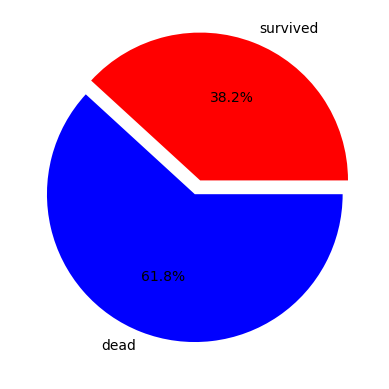

In [33]:
plt.pie([ser,dead],labels=['survived','dead'],colors=['red','blue'],autopct='%0.1f%%',explode=[0.1,0.0])
plt.show()

In [34]:
ser

np.int64(500)

In [35]:
## Hist :- 
#                  it is used to represent the count or understand the distribution of the data 
#      syntax:-    plt.hist(var['col_name'])

(array([809.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 500.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

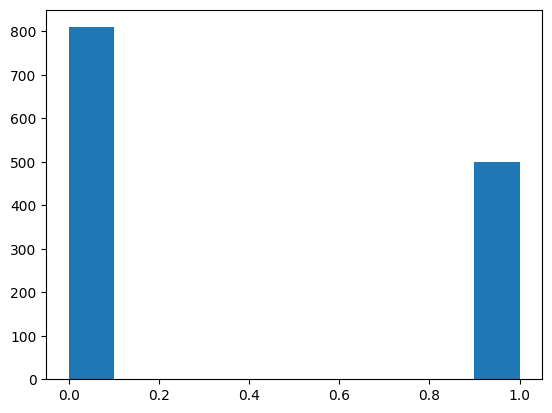

In [36]:
plt.hist(titnic['survived'])


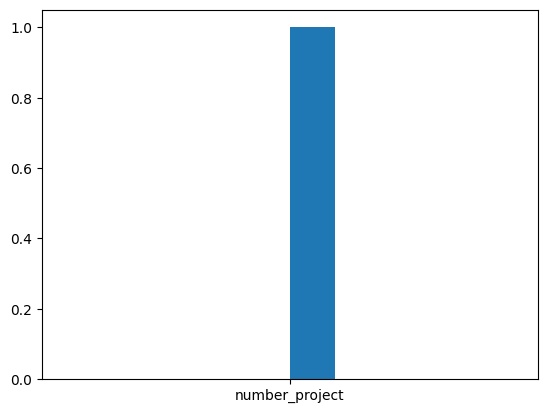

In [37]:
plt.hist(hr['number_project'])
plt.show()

In [38]:
hr = pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/hr_data.csv')

In [39]:
tips =pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/tips.csv')
tips

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...,...
239,239,29.03,5.92,Male,No,Sat,Dinner,3
240,240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,242,17.82,1.75,Male,No,Sat,Dinner,2


In [40]:
af= pd.read_csv('https://github.com/Taj1920/Data-Analysis-Datasets/raw/refs/heads/main/Datasets-Practice/amazon_fires.csv',encoding='ISO-8859-1')
af


,ano,mes,estado,numero,encontro
0,1998,Janeiro,Acre,0 Fires,1/1/1998
1,1999,Janeiro,Acre,0 Fires,1/1/1999
2,2000,Janeiro,Acre,0 Fires,1/1/2000
3,2001,Janeiro,Acre,0 Fires,1/1/2001
4,2002,Janeiro,Acre,0 Fires,1/1/2002
...,...,...,...,...,...
6449,2012,Dezembro,Tocantins,128,1/1/2012
6450,2013,Dezembro,Tocantins,85,1/1/2013
6451,2014,Dezembro,Tocantins,223,1/1/2014
6452,2015,Dezembro,Tocantins,373,1/1/2015


In [41]:
hr.head(2)

,employee_id,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,1003,2,157,3,0,1,0,sales,low
1,1005,5,262,6,0,1,0,sales,medium


In [42]:
hr['number_project'].unique()

array([2, 5, 7, 6, 4, 3])

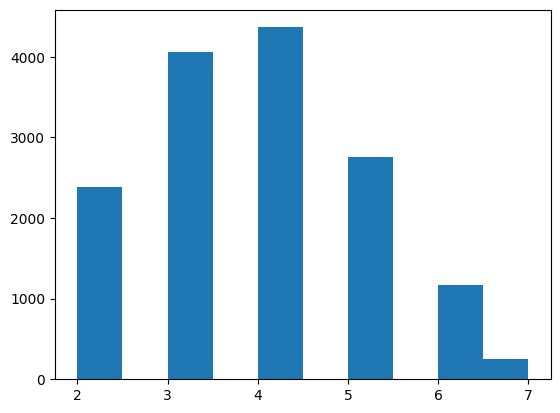

In [44]:
plt.hist(hr['number_project'])
plt.show()

(array([7316.,    0.,    0.,    0.,    0., 6446.,    0.,    0.,    0.,
        1237.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

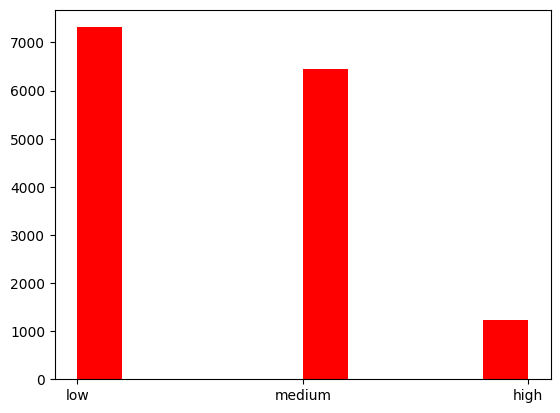

In [46]:
plt.hist(hr['salary'],color='red')

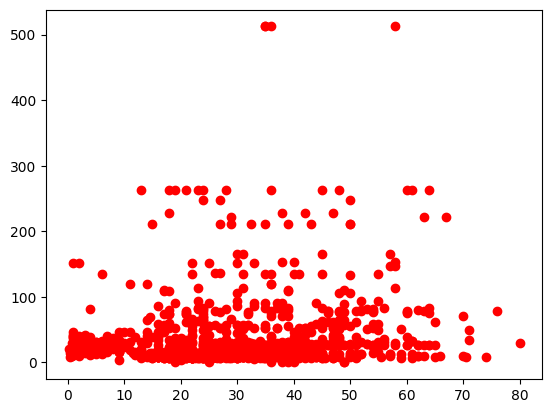

In [54]:
## Scatter():-
#         it is used ti analyse two columns a same time.
# 
##  Syntax:-   
#             plt.scatter(var['col_name'],var('col_name_2'))
# Value will  must be an instance of str or bytes not in a float

plt.scatter(titnic['age'],titnic['fare'],color='red')   

In [55]:
tips.head(2)

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3


Text(0.5, 0, 'total_bill')

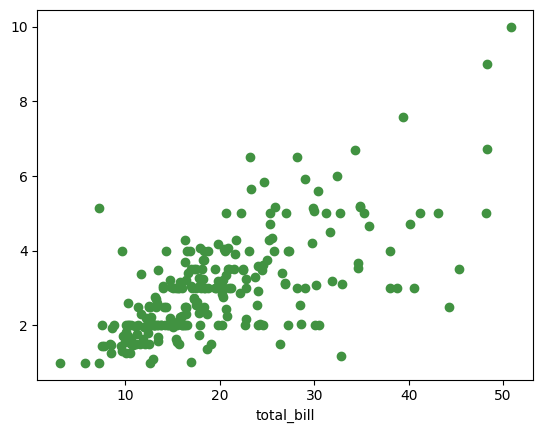

In [58]:
plt.scatter(tips['total_bill'],tips['tip'],color='#419241')
plt.xlabel('total_bill')

In [59]:
import seaborn as sns

##  Seaborn

it is mainly use for complex data .
#### Difference between Seaborn and Matplotlib
Seaborn :- 
1) it is use for complex data 
2)  it has more number plots.
3)  seaborn has more number of attributes
   

Matplotlib:-
1)   it is use for simple data
2)   it has limited plots
3)   it has limited attributes


### Types of plot in seaborn
1) Distribution plot
2) Categorical plot
3) Matrix plot
4) Regression Plot

#### types of plots
1) Univariate:-
                   if we plot the graph based in one column that is known as univariant
2) Bivariate :-       if the graph is based on two column that is known as bivariate
3)  Multivariate:-    if the graph is based on more than two column that is known as Multivariate
   

#### Distribution Plot:-
it help to understand how the data got distributed
##### Types of Distributed Plot
1)  histplot()
2)  joinplot()
3)  pairplot()